# Ce notebook est destiné à la modélisation. Nous testons deux modeles from scrach et un modele de transfert.

# 1. Configuration initiale

In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import pickle
from pathlib import Path
import time
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
from tensorflow.keras.applications import MobileNetV2, VGG16, ResNet50
from tensorflow.keras import models, layers
from tensorflow.keras.callbacks import EarlyStopping

# Configuration GPU
tf.config.optimizer.set_jit(True)
tf.config.optimizer.set_experimental_options({"auto_mixed_precision": True})

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
# Chemins
DATA_PATH = "/content/drive/MyDrive/ml_dogs/project/output2"
PROCESSOR_PATH = Path(DATA_PATH) / "processor_object_sample.pkl"
MODELS_SAVE_PATH = Path(DATA_PATH) / "trained_models"
MODELS_SAVE_PATH.mkdir(exist_ok=True)

# Variables globales
IMG_SIZE = 256
BATCH_SIZE = 32
DROPOUT_RATE = 0.2
results = {}

In [4]:
src_root = "/content/drive/MyDrive/ml_dogs/project/src"

import sys
sys.path.append(src_root)

from stanford_dogs_utils import (
    StanfordDogsProcessor,
    run_pipeline,
    show_pipeline_graph,
    save_processor_data
)

# 2. chargement des données

In [5]:
print("CHARGEMENT DES DONNÉES PREPROCESSÉES")
print("="*50)

# Charger le processeur
with open(PROCESSOR_PATH, 'rb') as f:
    processor = pickle.load(f)

num_classes = len(processor.breed_to_id)
print(f"Nombre de classes: {num_classes}")

# Créer les datasets
train_ds = processor.create_dataset('train', batch_size=BATCH_SIZE)
test_ds = processor.create_dataset('test', batch_size=BATCH_SIZE)

# Reformater et optimiser le pipeline des datasets
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.map(lambda x: (x['image'], x['label']), num_parallel_calls=tf.data.AUTOTUNE)
train_ds = train_ds.repeat()
train_ds = train_ds.cache()
train_ds = train_ds.prefetch(tf.data.AUTOTUNE)

test_ds = test_ds.map(lambda x: (x['image'], x['label']), num_parallel_calls=tf.data.AUTOTUNE)
test_ds = test_ds.cache()
test_ds = test_ds.prefetch(tf.data.AUTOTUNE)



print("Données chargées avec succès\n")

CHARGEMENT DES DONNÉES PREPROCESSÉES
Nombre de classes: 10

Creation du dataset TRAIN...
Dataset cree en 2.24s
Taille de batch: 32

Creation du dataset TEST...
Dataset cree en 0.03s
Taille de batch: 32
Données chargées avec succès



In [ ]:
train_ds

<_PrefetchDataset element_spec=(TensorSpec(shape=(32, 256, 256, 3), dtype=tf.float32, name=None), TensorSpec(shape=(32,), dtype=tf.int32, name=None))>

In [ ]:
test_ds

<_PrefetchDataset element_spec=(TensorSpec(shape=(32, 256, 256, 3), dtype=tf.float32, name=None), TensorSpec(shape=(32,), dtype=tf.int32, name=None))>

# 3. foctions utilitaires

In [6]:
def plot_metrics(history):
    """Affiche les courbes d'entraînement pour accuracy, loss, precision, recall"""
    metrics_list = ['accuracy', 'loss']
    # Ajouter precision et recall si disponibles
    if 'precision' in history.history:
        metrics_list.extend(['precision', 'recall'])

    for metric in metrics_list:
        plt.figure(figsize=(6, 4))
        plt.plot(history.history[metric], label=f'Train {metric}')
        plt.plot(history.history[f'val_{metric}'], label=f'Val {metric}')
        plt.title(f'{metric.capitalize()} au fil des époques')
        plt.xlabel('Époque')
        plt.ylabel(metric.capitalize())
        plt.legend()
        plt.grid(True)
        plt.tight_layout()
        plt.show()

def plot_confusion_matrix(model, test_ds, class_names, title):
    """Affiche la matrice de confusion"""
    # Prédictions
    y_pred_probs = model.predict(test_ds)
    y_pred = np.argmax(y_pred_probs, axis=1)

    # Labels vrais
    y_true = []
    for _, labels in test_ds:
        y_true.extend(labels.numpy())
    y_true = np.array(y_true)

    # Matrice de confusion
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)

    plt.figure(figsize=(12, 10))
    disp.plot(cmap='Blues', xticks_rotation=45)
    plt.title(f"Matrice de confusion - {title}")
    plt.tight_layout()
    plt.show()

    # Rapport de classification
    print(f"Rapport de classification - {title}:")
    print(classification_report(y_true, y_pred, target_names=class_names))

def resize_dataset_for_model(dataset, target_size):
    """Redimensionne un dataset pour une taille d'entrée spécifique"""
    def resize_fn(image, label):
        image = tf.image.resize(image, [target_size, target_size])
        return image, label

    return dataset.map(resize_fn, num_parallel_calls=tf.data.AUTOTUNE)

# 4. modélisation

## 4.1 CNN simpple

In [14]:
print(" MODÈLE 1: CNN SIMPLE (FROM SCRATCH)")
print("="*50)

def create_improved_simple_cnn():
    return tf.keras.Sequential([
        tf.keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3)),

        # Premier bloc - plus robuste
        tf.keras.layers.Conv2D(32, 3, padding='same', activation='relu'),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.Conv2D(32, 3, padding='same', activation='relu'),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.MaxPooling2D(2),
        tf.keras.layers.Dropout(0.25),

        # Deuxième bloc
        tf.keras.layers.Conv2D(64, 3, padding='same', activation='relu'),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.Conv2D(64, 3, padding='same', activation='relu'),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.MaxPooling2D(2),
        tf.keras.layers.Dropout(0.25),

        # Troisième bloc
        tf.keras.layers.Conv2D(128, 3, padding='same', activation='relu'),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.Conv2D(128, 3, padding='same', activation='relu'),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.MaxPooling2D(2),
        tf.keras.layers.Dropout(0.3),

        # Quatrième bloc
        tf.keras.layers.Conv2D(256, 3, padding='same', activation='relu'),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.GlobalAveragePooling2D(),
        tf.keras.layers.Dropout(0.5),

        # Classificateur amélioré
        tf.keras.layers.Dense(512, activation='relu'),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.Dropout(0.5),
        tf.keras.layers.Dense(256, activation='relu'),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.Dropout(0.3),
        tf.keras.layers.Dense(num_classes, activation='softmax')
    ])

# Créer et compiler
model1 = create_improved_simple_cnn()
model1.compile(
    optimizer=tf.keras.optimizers.Adam(0.001),
    loss='sparse_categorical_crossentropy',
    metrics=[
        'accuracy'#,
       # tf.keras.metrics.Precision(name='precision', average='macro'),
       # tf.keras.metrics.Recall(name='recall', average='macro')
    ]
)

print(f"Paramètres: {model1.count_params():,}")

# Callbacks
callbacks1 = [
    tf.keras.callbacks.EarlyStopping(monitor='val_accuracy', patience=15, restore_best_weights=True),
    tf.keras.callbacks.ReduceLROnPlateau(monitor='val_accuracy', factor=0.5, patience=5),
    tf.keras.callbacks.ModelCheckpoint(MODELS_SAVE_PATH / "improved_simple_cnn.h5", monitor='val_accuracy', save_best_only=True)
]

# Entraînement
start_time = time.time()
history1 = model1.fit(
    train_ds,
    epochs=50,
    validation_data=test_ds,
    callbacks=callbacks1,
    verbose=1,
    steps_per_epoch = int(num_classes * 100 / 32)
)
train_time1 = time.time() - start_time

# Évaluation
test_loss1, test_acc1 = model1.evaluate(test_ds, verbose=0)
results['Improved_Simple_CNN'] = {'accuracy': test_acc1, 'time': train_time1}

print(f"Improved Simple CNN - Précision: {test_acc1:.4f} - Temps: {train_time1:.1f}s")



🚀 MODÈLE 1: CNN SIMPLE AMÉLIORÉ (FROM SCRATCH)
Paramètres: 853,546
Epoch 1/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.1296 - loss: 3.1462

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/epoch_iterator.py:151: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


31/31 ━━━━━━━━━━━━━━━━━━━━ 16s 114ms/step - accuracy: 0.1305 - loss: 3.1405 - val_accuracy: 0.1190 - val_loss: 2.3184 - learning_rate: 0.0010
Epoch 2/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 48ms/step - accuracy: 0.2086 - loss: 2.5853 - val_accuracy: 0.0974 - val_loss: 2.9413 - learning_rate: 0.0010
Epoch 3/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 46ms/step - accuracy: 0.1778 - loss: 2.5924 - val_accuracy: 0.0805 - val_loss: 3.2155 - learning_rate: 0.0010
Epoch 4/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 46ms/step - accuracy: 0.2480 - loss: 2.3638 - val_accuracy: 0.0925 - val_loss: 2.8334 - learning_rate: 0.0010
Epoch 5/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 46ms/step - accuracy: 0.2800 - loss: 2.2776 - val_accuracy: 0.0986 - val_loss: 3.6136 - learning_rate: 0.0010
Epoch 6/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.2620 - loss: 2.1604

31/31 ━━━━━━━━━━━━━━━━━━━━ 2s 57ms/step - accuracy: 0.2622 - loss: 2.1599 - val_accuracy: 0.1238 - val_loss: 3.6196 - learning_rate: 0.0010
Epoch 7/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 48ms/step - accuracy: 0.2633 - loss: 2.1569 - val_accuracy: 0.1166 - val_loss: 3.8908 - learning_rate: 0.0010
Epoch 8/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.3073 - loss: 2.0988

31/31 ━━━━━━━━━━━━━━━━━━━━ 2s 55ms/step - accuracy: 0.3066 - loss: 2.0995 - val_accuracy: 0.1274 - val_loss: 4.6783 - learning_rate: 0.0010
Epoch 9/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 46ms/step - accuracy: 0.2791 - loss: 2.0605 - val_accuracy: 0.1094 - val_loss: 4.6770 - learning_rate: 0.0010
Epoch 10/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.2941 - loss: 1.9706

...

31/31 ━━━━━━━━━━━━━━━━━━━━ 2s 56ms/step - accuracy: 0.4603 - loss: 1.4368 - val_accuracy: 0.4639 - val_loss: 1.5334 - learning_rate: 0.0010
Epoch 34/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 46ms/step - accuracy: 0.4632 - loss: 1.4193 - val_accuracy: 0.3762 - val_loss: 1.7697 - learning_rate: 0.0010
Epoch 35/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 46ms/step - accuracy: 0.5457 - loss: 1.3115 - val_accuracy: 0.4519 - val_loss: 1.5482 - learning_rate: 0.0010
Epoch 36/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 46ms/step - accuracy: 0.5148 - loss: 1.3296 - val_accuracy: 0.4183 - val_loss: 1.6411 - learning_rate: 0.0010
Epoch 37/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 46ms/step - accuracy: 0.5192 - loss: 1.2694 - val_accuracy: 0.4243 - val_loss: 1.5661 - learning_rate: 0.0010
Epoch 38/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 46ms/step - accuracy: 0.5243 - loss: 1.2798 - val_accuracy: 0.3401 - val_loss: 1.9745 - learning_rate: 0.0010
Epoch 39/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.5488 - loss: 1.2338

31/31 ━━━━━━━━━━━━━━━━━━━━ 2s 58ms/step - accuracy: 0.5485 - loss: 1.2340 - val_accuracy: 0.4688 - val_loss: 1.4131 - learning_rate: 5.0000e-04
Epoch 40/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.5502 - loss: 1.2089

31/31 ━━━━━━━━━━━━━━━━━━━━ 2s 55ms/step - accuracy: 0.5501 - loss: 1.2088 - val_accuracy: 0.4832 - val_loss: 1.4591 - learning_rate: 5.0000e-04
Epoch 41/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 46ms/step - accuracy: 0.5172 - loss: 1.1948 - val_accuracy: 0.4267 - val_loss: 1.6750 - learning_rate: 5.0000e-04
Epoch 42/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 46ms/step - accuracy: 0.5851 - loss: 1.0893 - val_accuracy: 0.4159 - val_loss: 1.7015 - learning_rate: 5.0000e-04
Epoch 43/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 46ms/step - accuracy: 0.5736 - loss: 1.1438 - val_accuracy: 0.4531 - val_loss: 1.5570 - learning_rate: 5.0000e-04
Epoch 44/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 46ms/step - accuracy: 0.5837 - loss: 1.0706 - val_accuracy: 0.4375 - val_loss: 1.8105 - learning_rate: 5.0000e-04
Epoch 45/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 46ms/step - accuracy: 0.5960 - loss: 1.0701 - val_accuracy: 0.4171 - val_loss: 1.7495 - learning_rate: 5.0000e-04
Epoch 46/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 46ms/step - accuracy: 0.6222 - los

31/31 ━━━━━━━━━━━━━━━━━━━━ 2s 81ms/step - accuracy: 0.6450 - loss: 1.0281 - val_accuracy: 0.5012 - val_loss: 1.4688 - learning_rate: 2.5000e-04
Epoch 49/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.6371 - loss: 0.9244

31/31 ━━━━━━━━━━━━━━━━━━━━ 2s 56ms/step - accuracy: 0.6370 - loss: 0.9262 - val_accuracy: 0.5156 - val_loss: 1.4205 - learning_rate: 2.5000e-04
Epoch 50/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 46ms/step - accuracy: 0.6744 - loss: 0.9119 - val_accuracy: 0.4892 - val_loss: 1.4138 - learning_rate: 2.5000e-04
Improved Simple CNN - Précision: 0.5156 - Temps: 90.5s


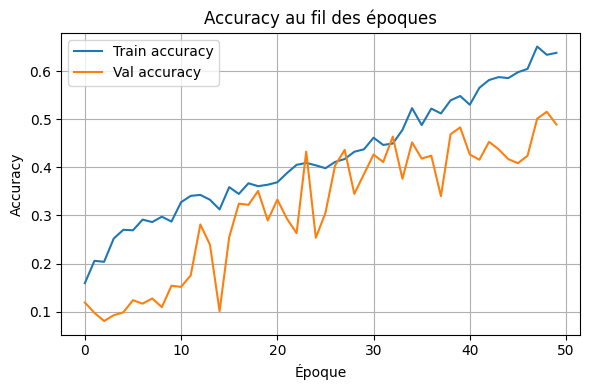

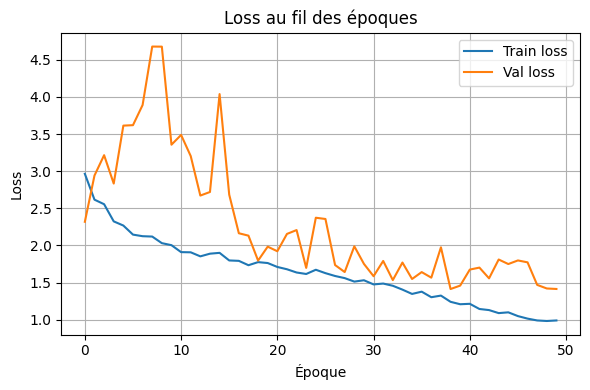

26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/epoch_iterator.py:151: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


<Figure size 1200x1000 with 0 Axes>

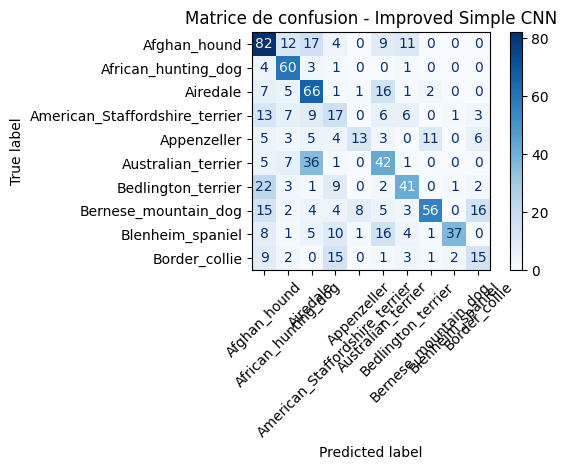

Rapport de classification - Improved Simple CNN:
                                precision    recall  f1-score   support

                  Afghan_hound       0.48      0.61      0.54       135
           African_hunting_dog       0.59      0.87      0.70        69
                      Airedale       0.45      0.67      0.54        99
American_Staffordshire_terrier       0.26      0.27      0.27        62
                   Appenzeller       0.57      0.26      0.36        50
            Australian_terrier       0.42      0.46      0.44        92
            Bedlington_terrier       0.58      0.51      0.54        81
          Bernese_mountain_dog       0.79      0.50      0.61       113
              Blenheim_spaniel       0.90      0.45      0.60        83
                 Border_collie       0.36      0.31      0.33        48

                      accuracy                           0.52       832
                     macro avg       0.54      0.49      0.49       832
             

In [16]:
# Visualisations
plot_metrics(history1)



26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/epoch_iterator.py:151: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


<Figure size 1200x1000 with 0 Axes>

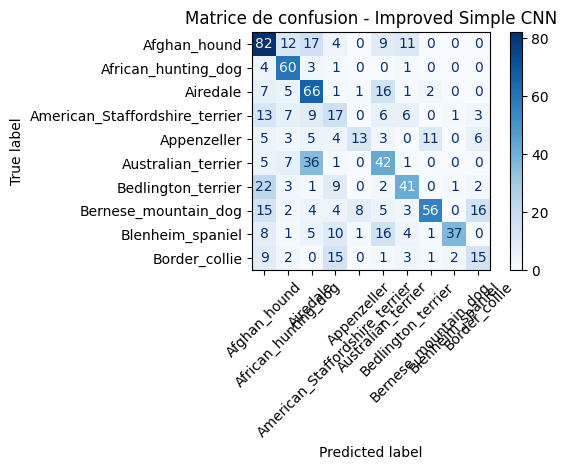

Rapport de classification - Improved Simple CNN:
                                precision    recall  f1-score   support

                  Afghan_hound       0.48      0.61      0.54       135
           African_hunting_dog       0.59      0.87      0.70        69
                      Airedale       0.45      0.67      0.54        99
American_Staffordshire_terrier       0.26      0.27      0.27        62
                   Appenzeller       0.57      0.26      0.36        50
            Australian_terrier       0.42      0.46      0.44        92
            Bedlington_terrier       0.58      0.51      0.54        81
          Bernese_mountain_dog       0.79      0.50      0.61       113
              Blenheim_spaniel       0.90      0.45      0.60        83
                 Border_collie       0.36      0.31      0.33        48

                      accuracy                           0.52       832
                     macro avg       0.54      0.49      0.49       832
             

In [17]:
plot_confusion_matrix(model1, test_ds, list(processor.breed_to_id.keys()), "Improved Simple CNN")

In [21]:
# Sauvegarder le modèle
model1.save(MODELS_SAVE_PATH / "cnn1.h5")

In [ ]:
# Nettoyer mémoire
del model1
tf.keras.backend.clear_session()

## 4.2 CNN avec attention

In [18]:
print("="*50)

def create_advanced_attention_cnn():
    inputs = tf.keras.layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3))

    # Stem initial plus robuste
    x = tf.keras.layers.Conv2D(32, 3, padding='same')(inputs)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.ReLU()(x)
    x = tf.keras.layers.Conv2D(32, 3, padding='same')(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.ReLU()(x)
    x = tf.keras.layers.MaxPooling2D(2)(x)
    x = tf.keras.layers.Dropout(0.25)(x)

    # Blocks avec attention et connexions résiduelles
    for i, filters in enumerate([64, 128, 256, 512]):
        # Connexion résiduelle
        residual = x

        # Première conv
        x = tf.keras.layers.SeparableConv2D(filters, 3, padding='same')(x)
        x = tf.keras.layers.BatchNormalization()(x)
        x = tf.keras.layers.ReLU()(x)

        # Deuxième conv
        x = tf.keras.layers.SeparableConv2D(filters, 3, padding='same')(x)
        x = tf.keras.layers.BatchNormalization()(x)

        # Ajustement de la connexion résiduelle
        if residual.shape[-1] != filters:
            residual = tf.keras.layers.Conv2D(filters, 1)(residual)
            residual = tf.keras.layers.BatchNormalization()(residual)

        x = tf.keras.layers.Add()([x, residual])
        x = tf.keras.layers.ReLU()(x)

        # Mécanisme d'attention channel
        channel_attention = tf.keras.layers.GlobalAveragePooling2D()(x)
        channel_attention = tf.keras.layers.Dense(filters // 8, activation='relu')(channel_attention)
        channel_attention = tf.keras.layers.Dense(filters, activation='sigmoid')(channel_attention)
        channel_attention = tf.keras.layers.Reshape((1, 1, filters))(channel_attention)

        # Mécanisme d'attention spatial
        spatial_attention = tf.keras.layers.Conv2D(1, 7, padding='same', activation='sigmoid')(x)

        # Application des attentions
        x = tf.keras.layers.Multiply()([x, channel_attention])
        x = tf.keras.layers.Multiply()([x, spatial_attention])

        # Pooling et dropout progressif
        if i < len([64, 128, 256, 512]) - 1:  # Pas de pooling pour le dernier bloc
            x = tf.keras.layers.MaxPooling2D(2)(x)
        x = tf.keras.layers.Dropout(0.2 + i * 0.1)(x)

    # Head de classification amélioré
    x = tf.keras.layers.GlobalAveragePooling2D()(x)
    x = tf.keras.layers.Dense(512, activation='relu')(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.Dropout(0.5)(x)
    x = tf.keras.layers.Dense(256, activation='relu')(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.Dropout(0.3)(x)
    outputs = tf.keras.layers.Dense(num_classes, activation='softmax')(x)

    return tf.keras.Model(inputs, outputs)

# Créer et compiler
model2 = create_advanced_attention_cnn()
model2.compile(
    optimizer=tf.keras.optimizers.Adam(0.001),
    loss='sparse_categorical_crossentropy',
    metrics=[
        'accuracy'#,
        #tf.keras.metrics.Precision(name='precision'),
        #tf.keras.metrics.Recall(name='recall')
    ]
)

print(f"Paramètres: {model2.count_params():,}")

# Callbacks
callbacks2 = [
    tf.keras.callbacks.EarlyStopping(monitor='val_accuracy', patience=15, restore_best_weights=True),
    tf.keras.callbacks.ReduceLROnPlateau(monitor='val_accuracy', factor=0.5, patience=5),
    tf.keras.callbacks.ModelCheckpoint(MODELS_SAVE_PATH / "advanced_attention_cnn.h5", monitor='val_accuracy', save_best_only=True)
]

# Entraînement
start_time = time.time()
history2 = model2.fit(
    train_ds,
    epochs=50,
    validation_data=test_ds,
    callbacks=callbacks2,
    verbose=1,
    steps_per_epoch = int(num_classes * 100 / 32)
)
train_time2 = time.time() - start_time

# Évaluation
test_loss2, test_acc2 = model2.evaluate(test_ds, verbose=0)
results['Advanced_Attention_CNN'] = {'accuracy': test_acc2, 'time': train_time2}

print(f"Advanced Attention CNN - Précision: {test_acc2:.4f} - Temps: {train_time2:.1f}s")



 MODÈLE 2: CNN AVEC ATTENTION AMÉLIORÉ (FROM SCRATCH)
Paramètres: 1,268,870
Epoch 1/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - accuracy: 0.0994 - loss: 3.1803

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/epoch_iterator.py:151: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


31/31 ━━━━━━━━━━━━━━━━━━━━ 36s 195ms/step - accuracy: 0.0998 - loss: 3.1764 - val_accuracy: 0.0829 - val_loss: 2.3129 - learning_rate: 0.0010
Epoch 2/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 2s 66ms/step - accuracy: 0.1348 - loss: 2.8193 - val_accuracy: 0.0829 - val_loss: 2.3037 - learning_rate: 0.0010
Epoch 3/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - accuracy: 0.1479 - loss: 2.6385

31/31 ━━━━━━━━━━━━━━━━━━━━ 2s 78ms/step - accuracy: 0.1476 - loss: 2.6390 - val_accuracy: 0.1623 - val_loss: 2.3035 - learning_rate: 0.0010
Epoch 4/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 2s 67ms/step - accuracy: 0.1559 - loss: 2.5188 - val_accuracy: 0.0829 - val_loss: 2.3967 - learning_rate: 0.0010
Epoch 5/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 2s 67ms/step - accuracy: 0.1474 - loss: 2.4304 - val_accuracy: 0.0974 - val_loss: 2.4556 - learning_rate: 0.0010
Epoch 6/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 2s 66ms/step - accuracy: 0.2077 - loss: 2.2855 - val_accuracy: 0.0998 - val_loss: 2.5206 - learning_rate: 0.0010
Epoch 7/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 2s 72ms/step - accuracy: 0.1507 - loss: 2.3665 - val_accuracy: 0.0998 - val_loss: 2.5077 - learning_rate: 0.0010
Epoch 8/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 2s 66ms/step - accuracy: 0.2067 - loss: 2.3057 - val_accuracy: 0.1106 - val_loss: 2.6517 - learning_rate: 0.0010
Epoch 9/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 2s 65ms/step - accuracy: 0.1913 - loss: 2.1864 - val_accuracy: 0.09

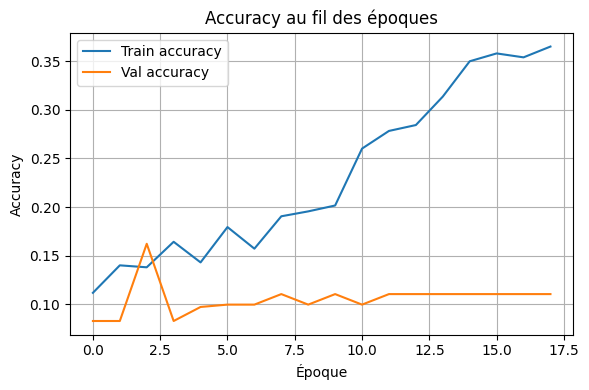

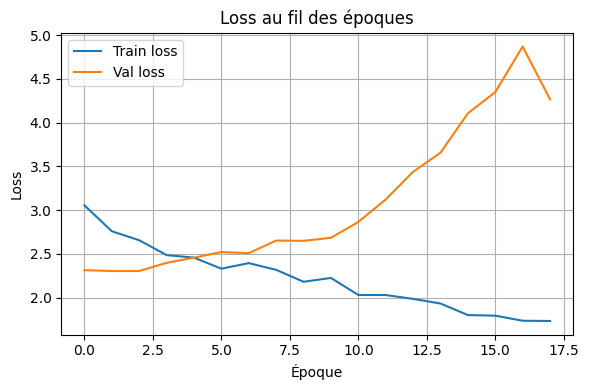

26/26 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/epoch_iterator.py:151: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


<Figure size 1200x1000 with 0 Axes>

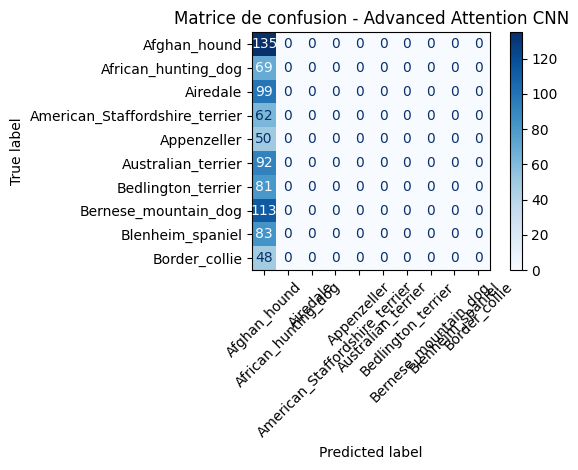

Rapport de classification - Advanced Attention CNN:
                                precision    recall  f1-score   support

                  Afghan_hound       0.16      1.00      0.28       135
           African_hunting_dog       0.00      0.00      0.00        69
                      Airedale       0.00      0.00      0.00        99
American_Staffordshire_terrier       0.00      0.00      0.00        62
                   Appenzeller       0.00      0.00      0.00        50
            Australian_terrier       0.00      0.00      0.00        92
            Bedlington_terrier       0.00      0.00      0.00        81
          Bernese_mountain_dog       0.00      0.00      0.00       113
              Blenheim_spaniel       0.00      0.00      0.00        83
                 Border_collie       0.00      0.00      0.00        48

                      accuracy                           0.16       832
                     macro avg       0.02      0.10      0.03       832
          

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [19]:
# Visualisations
plot_metrics(history2)
plot_confusion_matrix(model2, test_ds, list(processor.breed_to_id.keys()), "Advanced Attention CNN")



In [20]:
# Sauvegarder le modèle
model2.save(MODELS_SAVE_PATH / "cnn2.h5")

In [ ]:
# Nettoyer mémoire
del model2
tf.keras.backend.clear_session()

# 4.3 MobileNetV2 (modèle de transfert)

In [24]:
# Redimensionner les datasets pour MobileNetV2 (224x224)
MOBILENET_SIZE = 224
train_ds_mobilenet = resize_dataset_for_model(train_ds, MOBILENET_SIZE)
test_ds_mobilenet = resize_dataset_for_model(test_ds, MOBILENET_SIZE)

base_model = MobileNetV2(
    include_top=False,
    weights='imagenet',
    input_shape=(MOBILENET_SIZE, MOBILENET_SIZE, 3)
)
base_model.trainable = False

model3 = models.Sequential([
    base_model,
    layers.Conv2D(32, kernel_size=3, activation='relu'),
    layers.GlobalAveragePooling2D(),
    layers.BatchNormalization(),
    layers.Dropout(DROPOUT_RATE),
    layers.Dense(128, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(DROPOUT_RATE),
    layers.Dense(num_classes, activation='softmax')
])

model3.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=[
        'accuracy'#,
        #tf.keras.metrics.Precision(name='precision'),
        #tf.keras.metrics.Recall(name='recall')
    ]
)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

start_time = time.time()
history3 = model3.fit(
    train_ds_mobilenet,
    validation_data=test_ds_mobilenet,
    epochs=30,
    callbacks=[early_stop],
    verbose=2,
    steps_per_epoch = int(num_classes * 100 / 32)
)
train_time3 = time.time() - start_time

test_loss3, test_acc3 = model3.evaluate(test_ds_mobilenet, verbose=0)
results['MobileNetV2'] = {'accuracy': test_acc3, 'time': train_time3}

print(f"MobileNetV2 - Précision: {test_acc3:.4f} - Temps: {train_time3:.1f}s")




🚀 MODÈLE 3: MobileNetV2 AMÉLIORÉ (TRANSFER LEARNING)
Epoch 1/30


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/epoch_iterator.py:151: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


31/31 - 13s - 434ms/step - accuracy: 0.8125 - loss: 0.6576 - val_accuracy: 0.8678 - val_loss: 0.3852
Epoch 2/30
31/31 - 1s - 34ms/step - accuracy: 0.9647 - loss: 0.1707 - val_accuracy: 0.9700 - val_loss: 0.1290
Epoch 3/30
31/31 - 1s - 40ms/step - accuracy: 0.9798 - loss: 0.1014 - val_accuracy: 0.9736 - val_loss: 0.1045
Epoch 4/30
31/31 - 1s - 41ms/step - accuracy: 0.9869 - loss: 0.0630 - val_accuracy: 0.9736 - val_loss: 0.0789
Epoch 5/30
31/31 - 1s - 37ms/step - accuracy: 0.9879 - loss: 0.0514 - val_accuracy: 0.9724 - val_loss: 0.0898
Epoch 6/30
31/31 - 1s - 44ms/step - accuracy: 0.9929 - loss: 0.0387 - val_accuracy: 0.9760 - val_loss: 0.0642
Epoch 7/30
31/31 - 1s - 38ms/step - accuracy: 0.9950 - loss: 0.0263 - val_accuracy: 0.9772 - val_loss: 0.0683
Epoch 8/30
31/31 - 1s - 46ms/step - accuracy: 0.9940 - loss: 0.0262 - val_accuracy: 0.9784 - val_loss: 0.0589
Epoch 9/30
31/31 - 1s - 43ms/step - accuracy: 0.9970 - loss: 0.0214 - val_accuracy: 0.9844 - val_loss: 0.0513
Epoch 10/30
31/31 -

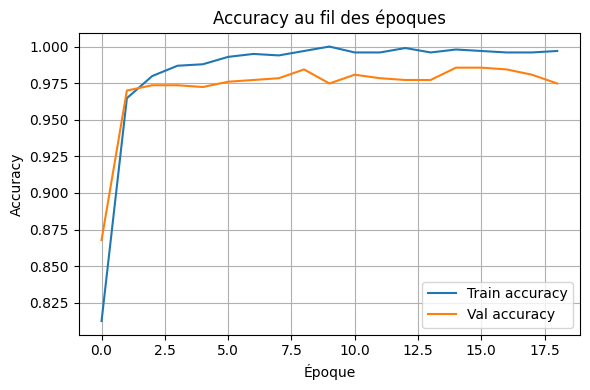

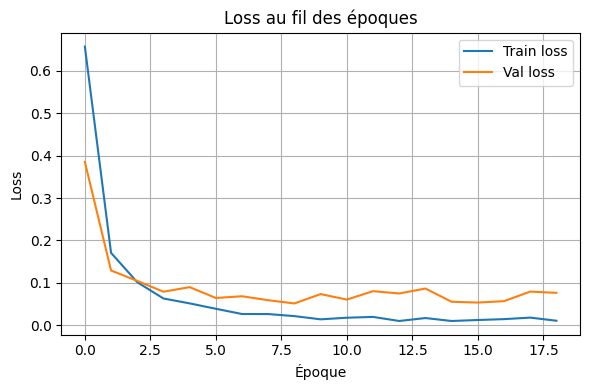

26/26 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step


<Figure size 1200x1000 with 0 Axes>

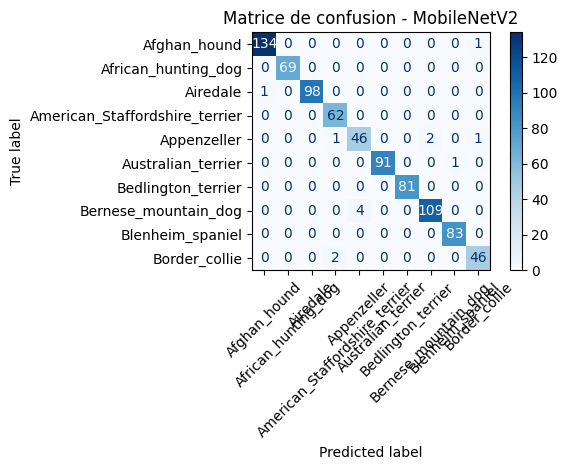

Rapport de classification - MobileNetV2:
                                precision    recall  f1-score   support

                  Afghan_hound       0.99      0.99      0.99       135
           African_hunting_dog       1.00      1.00      1.00        69
                      Airedale       1.00      0.99      0.99        99
American_Staffordshire_terrier       0.95      1.00      0.98        62
                   Appenzeller       0.92      0.92      0.92        50
            Australian_terrier       1.00      0.99      0.99        92
            Bedlington_terrier       1.00      1.00      1.00        81
          Bernese_mountain_dog       0.98      0.96      0.97       113
              Blenheim_spaniel       0.99      1.00      0.99        83
                 Border_collie       0.96      0.96      0.96        48

                      accuracy                           0.98       832
                     macro avg       0.98      0.98      0.98       832
                  wei

In [25]:
# Visualisations
plot_metrics(history3)
plot_confusion_matrix(model3, test_ds_mobilenet, list(processor.breed_to_id.keys()), "MobileNetV2")


In [26]:
# Sauvegarder le modèle
model3.save(MODELS_SAVE_PATH / "mobilenetv2_improved.h5")

# Nettoyer mémoire
del model3, base_model
tf.keras.backend.clear_session()

## 4.4 VGG16 (modèle de transfert)

In [27]:
# Redimensionner les datasets pour VGG16 (224x224)
VGG_SIZE = 224
train_ds_vgg = resize_dataset_for_model(train_ds, VGG_SIZE)
test_ds_vgg = resize_dataset_for_model(test_ds, VGG_SIZE)

base_model_vgg = VGG16(
    input_shape=(VGG_SIZE, VGG_SIZE, 3),
    include_top=False,
    weights='imagenet'
)
base_model_vgg.trainable = False

model4 = models.Sequential([
    base_model_vgg,
    layers.Flatten(),
    layers.Dense(512, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(DROPOUT_RATE),
    layers.Dense(256, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(DROPOUT_RATE),
    layers.Dense(num_classes, activation='softmax')
])

model4.compile(
    optimizer=tf.keras.optimizers.Adam(),
    loss='sparse_categorical_crossentropy',
    metrics=[
        'accuracy'#,
        #tf.keras.metrics.Precision(name='precision'),
        #tf.keras.metrics.Recall(name='recall')
    ]
)

early_stop_vgg = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

start_time = time.time()
history4 = model4.fit(
    train_ds_vgg,
    validation_data=test_ds_vgg,
    epochs=30,
    callbacks=[early_stop_vgg],
    verbose=2,
    steps_per_epoch = int(num_classes * 100 / 32)
)
train_time4 = time.time() - start_time

test_loss4, test_acc4 = model4.evaluate(test_ds_vgg, verbose=0)
results['VGG16'] = {'accuracy': test_acc4, 'time': train_time4}

print(f"VGG16 - Précision: {test_acc4:.4f} - Temps: {train_time4:.1f}s")



 MODÈLE 4: VGG16 (TRANSFER LEARNING)
Epoch 1/30
31/31 - 7s - 222ms/step - accuracy: 0.5171 - loss: 1.5792 - val_accuracy: 0.1899 - val_loss: 5.5835
Epoch 2/30


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/epoch_iterator.py:151: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


31/31 - 1s - 38ms/step - accuracy: 0.9143 - loss: 0.3001 - val_accuracy: 0.3774 - val_loss: 2.5304
Epoch 3/30
31/31 - 1s - 41ms/step - accuracy: 0.9768 - loss: 0.1100 - val_accuracy: 0.5733 - val_loss: 1.4240
Epoch 4/30
31/31 - 2s - 49ms/step - accuracy: 0.9950 - loss: 0.0482 - val_accuracy: 0.6995 - val_loss: 0.9105
Epoch 5/30
31/31 - 1s - 43ms/step - accuracy: 0.9970 - loss: 0.0372 - val_accuracy: 0.7091 - val_loss: 0.8244
Epoch 6/30
31/31 - 1s - 43ms/step - accuracy: 0.9970 - loss: 0.0325 - val_accuracy: 0.7656 - val_loss: 0.7050
Epoch 7/30
31/31 - 1s - 43ms/step - accuracy: 0.9980 - loss: 0.0235 - val_accuracy: 0.8041 - val_loss: 0.6094
Epoch 8/30
31/31 - 1s - 43ms/step - accuracy: 1.0000 - loss: 0.0120 - val_accuracy: 0.8005 - val_loss: 0.5893
Epoch 9/30
31/31 - 1s - 45ms/step - accuracy: 0.9960 - loss: 0.0184 - val_accuracy: 0.8017 - val_loss: 0.5881
Epoch 10/30
31/31 - 1s - 42ms/step - accuracy: 1.0000 - loss: 0.0111 - val_accuracy: 0.8029 - val_loss: 0.5895
Epoch 11/30
31/31 - 

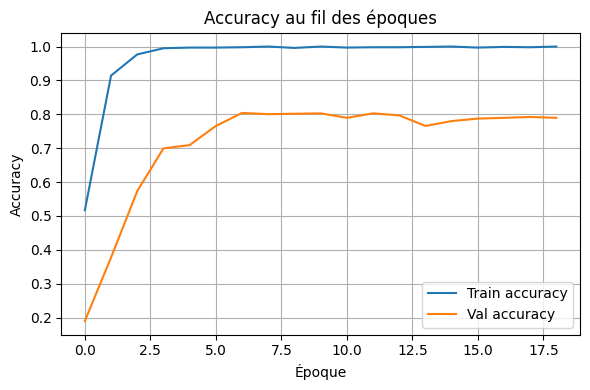

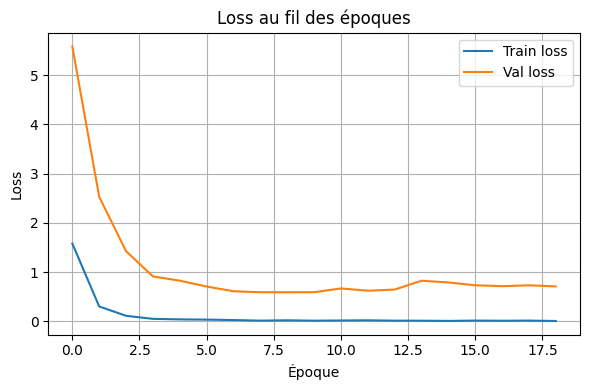

26/26 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step


<Figure size 1200x1000 with 0 Axes>

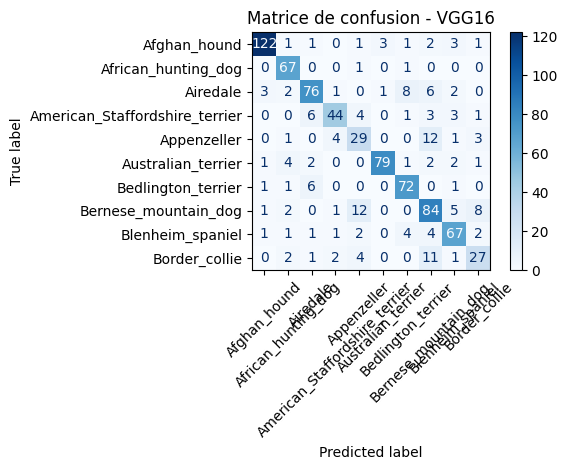

Rapport de classification - VGG16:
                                precision    recall  f1-score   support

                  Afghan_hound       0.95      0.90      0.92       135
           African_hunting_dog       0.83      0.97      0.89        69
                      Airedale       0.82      0.77      0.79        99
American_Staffordshire_terrier       0.83      0.71      0.77        62
                   Appenzeller       0.55      0.58      0.56        50
            Australian_terrier       0.95      0.86      0.90        92
            Bedlington_terrier       0.82      0.89      0.85        81
          Bernese_mountain_dog       0.68      0.74      0.71       113
              Blenheim_spaniel       0.79      0.81      0.80        83
                 Border_collie       0.63      0.56      0.59        48

                      accuracy                           0.80       832
                     macro avg       0.78      0.78      0.78       832
                  weighted 

In [28]:
# Visualisations
plot_metrics(history4)
plot_confusion_matrix(model4, test_ds_vgg, list(processor.breed_to_id.keys()), "VGG16")



In [29]:
# Sauvegarder le modèle
model4.save(MODELS_SAVE_PATH / "vgg16_improved.h5")

# Nettoyer mémoire
del model4, base_model_vgg
tf.keras.backend.clear_session()

## ResNet50 modèle de transfert

In [30]:
# Redimensionner les datasets pour ResNet50 (224x224)
RESNET_SIZE = 224
train_ds_resnet = resize_dataset_for_model(train_ds, RESNET_SIZE)
test_ds_resnet = resize_dataset_for_model(test_ds, RESNET_SIZE)

base_model_resnet = ResNet50(
    input_shape=(RESNET_SIZE, RESNET_SIZE, 3),
    include_top=False,
    weights='imagenet'
)
base_model_resnet.trainable = False

model5 = models.Sequential([
    base_model_resnet,
    layers.GlobalAveragePooling2D(),
    layers.Dense(512, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(DROPOUT_RATE),
    layers.Dense(256, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(DROPOUT_RATE),
    layers.Dense(num_classes, activation='softmax')
])

model5.compile(
    optimizer=tf.keras.optimizers.Adam(),
    loss='sparse_categorical_crossentropy',
    metrics=[
        'accuracy'#,
        #tf.keras.metrics.Precision(name='precision'),
        #tf.keras.metrics.Recall(name='recall')
    ]
)

early_stop_resnet = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

start_time = time.time()
history5 = model5.fit(
    train_ds_resnet,
    validation_data=test_ds_resnet,
    epochs=30,
    callbacks=[early_stop_resnet],
    verbose=2,
    steps_per_epoch=int(num_classes * 100 / BATCH_SIZE)
)
train_time5 = time.time() - start_time

test_loss5, test_acc5 = model5.evaluate(test_ds_resnet, verbose=0)
results['ResNet50'] = {'accuracy': test_acc5, 'time': train_time5}

print(f"ResNet50 - Précision: {test_acc5:.4f} - Temps: {train_time5:.1f}s")



 MODÈLE 5: ResNet50 (TRANSFER LEARNING)
Epoch 1/30


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/epoch_iterator.py:151: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


31/31 - 17s - 561ms/step - accuracy: 0.2036 - loss: 2.4404 - val_accuracy: 0.0745 - val_loss: 2.8966
Epoch 2/30
31/31 - 1s - 39ms/step - accuracy: 0.3377 - loss: 1.9723 - val_accuracy: 0.0625 - val_loss: 2.9961
Epoch 3/30
31/31 - 1s - 46ms/step - accuracy: 0.3921 - loss: 1.7880 - val_accuracy: 0.0805 - val_loss: 2.8025
Epoch 4/30
31/31 - 1s - 39ms/step - accuracy: 0.4395 - loss: 1.6229 - val_accuracy: 0.0601 - val_loss: 3.1763
Epoch 5/30
31/31 - 1s - 40ms/step - accuracy: 0.4657 - loss: 1.5650 - val_accuracy: 0.0601 - val_loss: 3.2316
Epoch 6/30
31/31 - 1s - 47ms/step - accuracy: 0.4990 - loss: 1.4361 - val_accuracy: 0.1406 - val_loss: 2.5494
Epoch 7/30
31/31 - 1s - 38ms/step - accuracy: 0.5454 - loss: 1.3280 - val_accuracy: 0.0745 - val_loss: 3.0008
Epoch 8/30
31/31 - 1s - 40ms/step - accuracy: 0.5696 - loss: 1.2651 - val_accuracy: 0.1863 - val_loss: 3.2333
Epoch 9/30
31/31 - 1s - 48ms/step - accuracy: 0.5776 - loss: 1.1823 - val_accuracy: 0.2043 - val_loss: 2.4912
Epoch 10/30
31/31 -

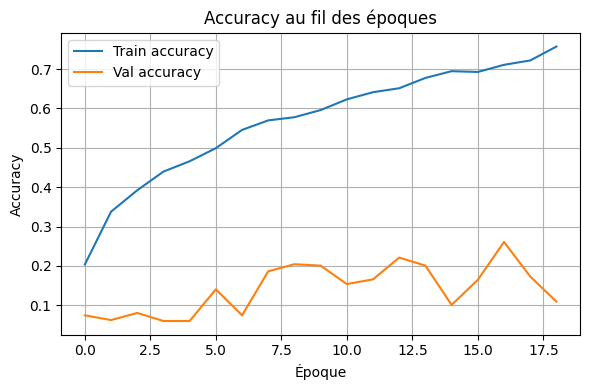

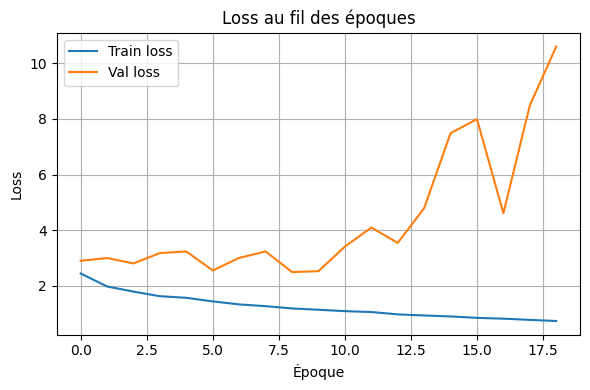

26/26 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/step


<Figure size 1200x1000 with 0 Axes>

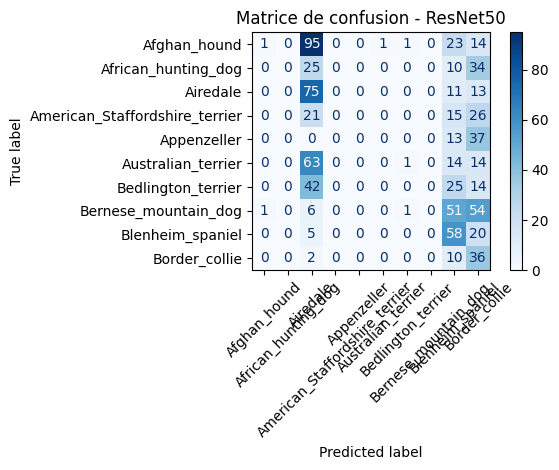

Rapport de classification - ResNet50:
                                precision    recall  f1-score   support

                  Afghan_hound       0.50      0.01      0.01       135
           African_hunting_dog       0.00      0.00      0.00        69
                      Airedale       0.22      0.76      0.35        99
American_Staffordshire_terrier       0.00      0.00      0.00        62
                   Appenzeller       0.00      0.00      0.00        50
            Australian_terrier       0.00      0.00      0.00        92
            Bedlington_terrier       0.00      0.00      0.00        81
          Bernese_mountain_dog       0.00      0.00      0.00       113
              Blenheim_spaniel       0.25      0.70      0.37        83
                 Border_collie       0.14      0.75      0.23        48

                      accuracy                           0.20       832
                     macro avg       0.11      0.22      0.10       832
                  weight

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [31]:
# Visualisations
plot_metrics(history5)
plot_confusion_matrix(model5, test_ds_resnet, list(processor.breed_to_id.keys()), "ResNet50")



In [32]:
# Sauvegarder le modèle
model5.save(MODELS_SAVE_PATH / "resnet50_improved.h5")

# Nettoyer mémoire
del model5, base_model_resnet
tf.keras.backend.clear_session()

# 5. comparaison des modeles

 COMPARAISON FINALE DES MODÈLES
Modèle                    Précision    Temps (s) 
--------------------------------------------------
MobileNetV2               0.9844       36.7      
VGG16                     0.8017       31.1      
Improved_Simple_CNN       0.5156       90.5      
ResNet50                  0.2043       41.2      
Advanced_Attention_CNN    0.1623       71.4      


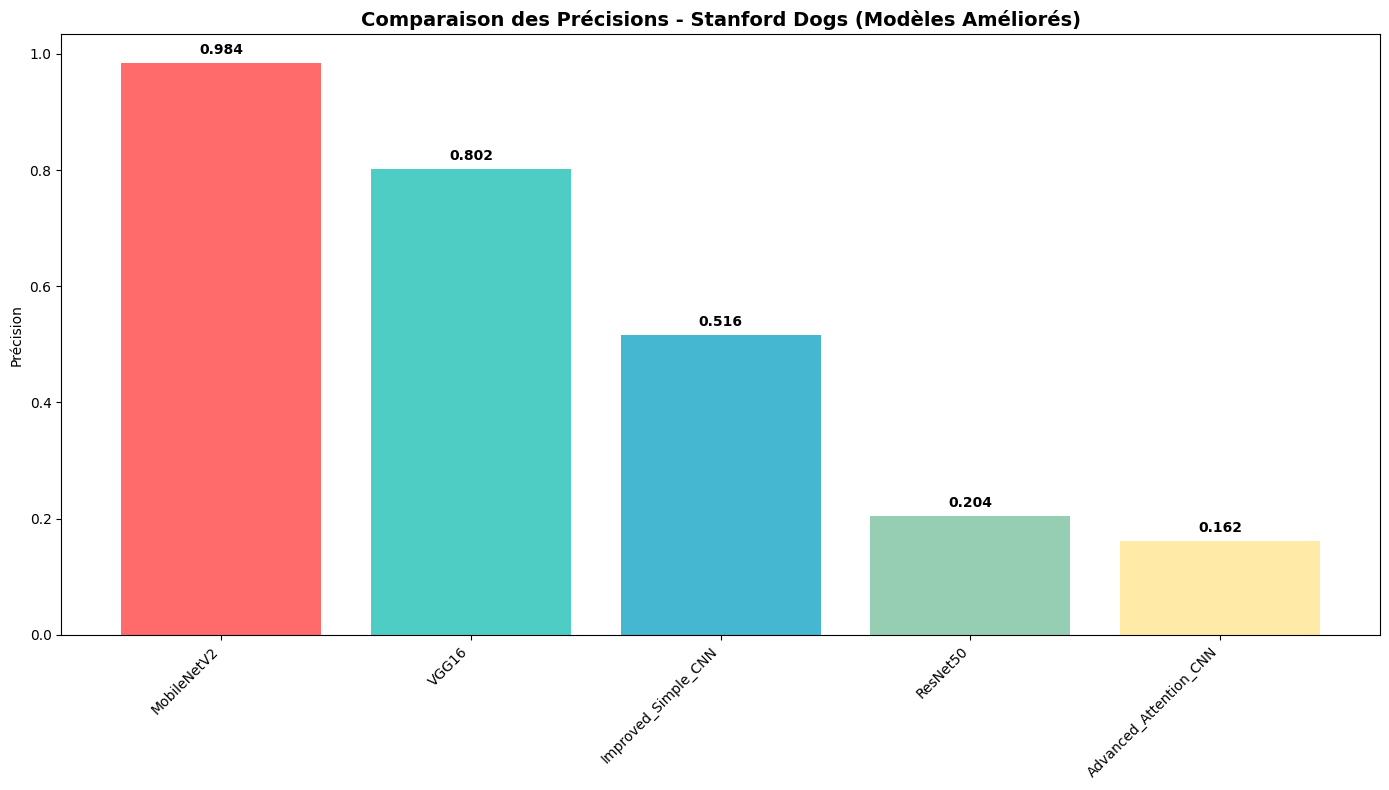


 MEILLEUR MODÈLE: MobileNetV2 - 0.9844
 Modèles sauvegardés dans: /content/drive/MyDrive/ml_dogs/project/output2/trained_models
 ENTRAÎNEMENT TERMINÉ!


In [33]:
# Trier par précision
sorted_results = sorted(results.items(), key=lambda x: x[1]['accuracy'], reverse=True)

print(f"{'Modèle':<25} {'Précision':<12} {'Temps (s)':<10}")
print("-" * 50)

for model_name, result in sorted_results:
    print(f"{model_name:<25} {result['accuracy']:<12.4f} {result['time']:<10.1f}")

# Graphique comparatif
names = [name for name, _ in sorted_results]
accuracies = [result['accuracy'] for _, result in sorted_results]

plt.figure(figsize=(14, 8))
bars = plt.bar(names, accuracies, color=['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4', '#FFEAA7'])
plt.title('Comparaison des Précisions - Stanford Dogs (Modèles Améliorés)', fontsize=14, fontweight='bold')
plt.ylabel('Précision')
plt.xticks(rotation=45, ha='right')

for bar, acc in zip(bars, accuracies):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f'{acc:.3f}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

# Sauvegarder résultats
with open(MODELS_SAVE_PATH / "improved_results.pkl", 'wb') as f:
    pickle.dump(results, f)

print(f"\n MEILLEUR MODÈLE: {sorted_results[0][0]} - {sorted_results[0][1]['accuracy']:.4f}")
print(f" Modèles sauvegardés dans: {MODELS_SAVE_PATH}")
print(" ENTRAÎNEMENT TERMINÉ!")